In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [3]:
# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension: (28, 28) -> (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


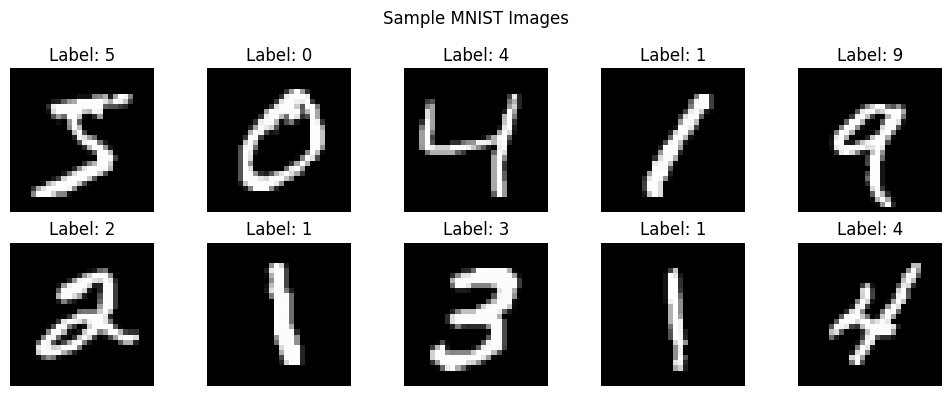

In [4]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

In [5]:
def build_model(dropout_rate=0.3, learning_rate=0.001, filters1=32, filters2=64):
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(filters1, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(filters2, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9199 - loss: 0.2641 - val_accuracy: 0.9808 - val_loss: 0.0647
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9774 - loss: 0.0754 - val_accuracy: 0.9877 - val_loss: 0.0432
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9838 - loss: 0.0525 - val_accuracy: 0.9905 - val_loss: 0.0366
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9875 - loss: 0.0418 - val_accuracy: 0.9885 - val_loss: 0.0370
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9888 - loss: 0.0348 - val_accuracy: 0.9897 - val_loss: 0.0384
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9907 - loss: 0.0298 - val_accuracy: 0.9895 - val_loss: 0.0379


In [7]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0361
Test Accuracy: 0.9885


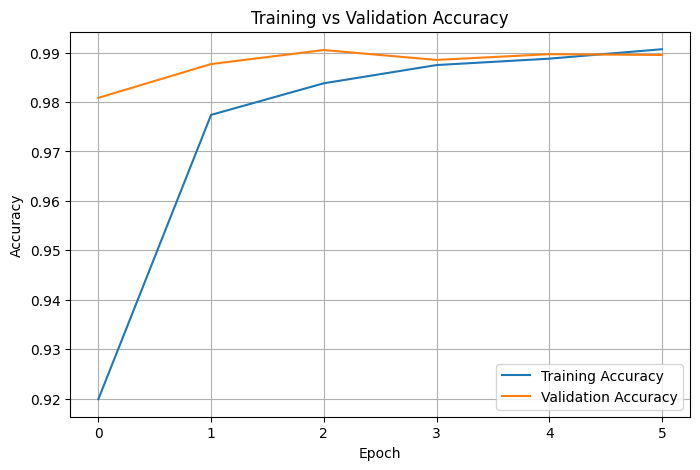

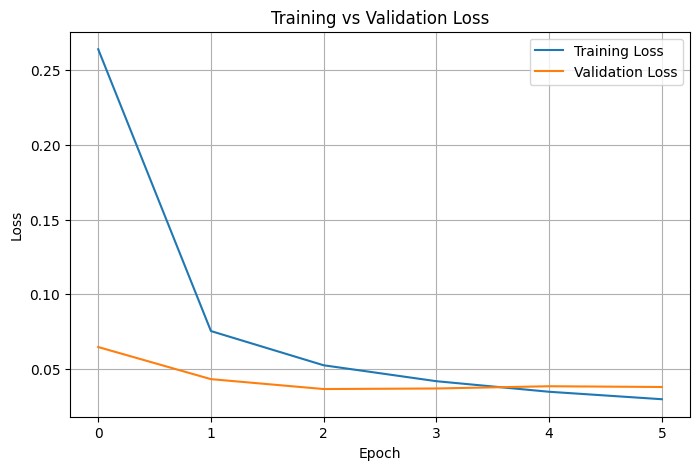

In [8]:
# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


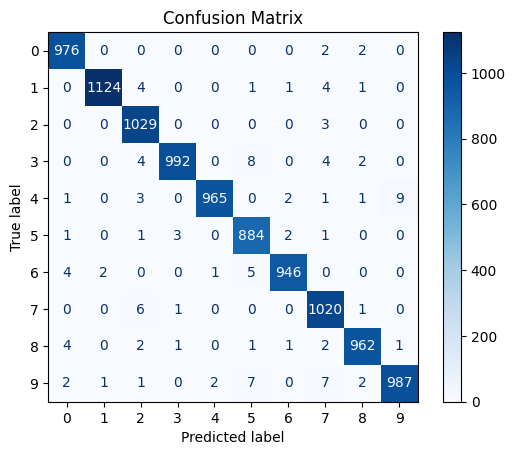

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.98      1.00      0.99      1032
           3       0.99      0.98      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [9]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

Filter shape: (3, 3, 1, 32)


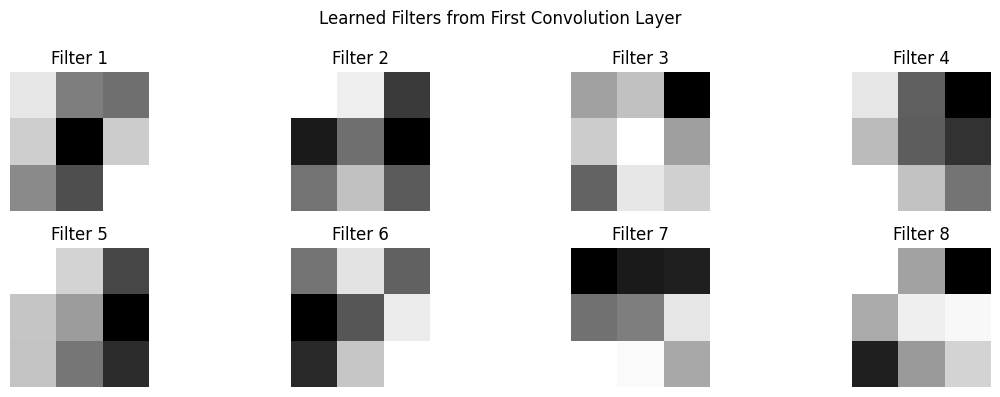

In [10]:
# Get weights from the first Conv2D layer
filters, biases = model.layers[0].get_weights()

print("Filter shape:", filters.shape)  # (3, 3, 1, 32)

num_filters = 8
plt.figure(figsize=(12, 4))

for i in range(num_filters):
    f = filters[:, :, 0, i]
    plt.subplot(2, 4, i + 1)
    plt.imshow(f, cmap='gray')
    plt.title(f'Filter {i+1}')
    plt.axis('off')

plt.suptitle("Learned Filters from First Convolution Layer")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step


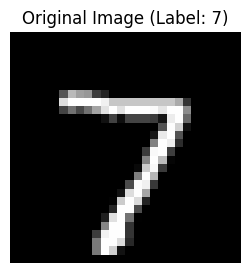

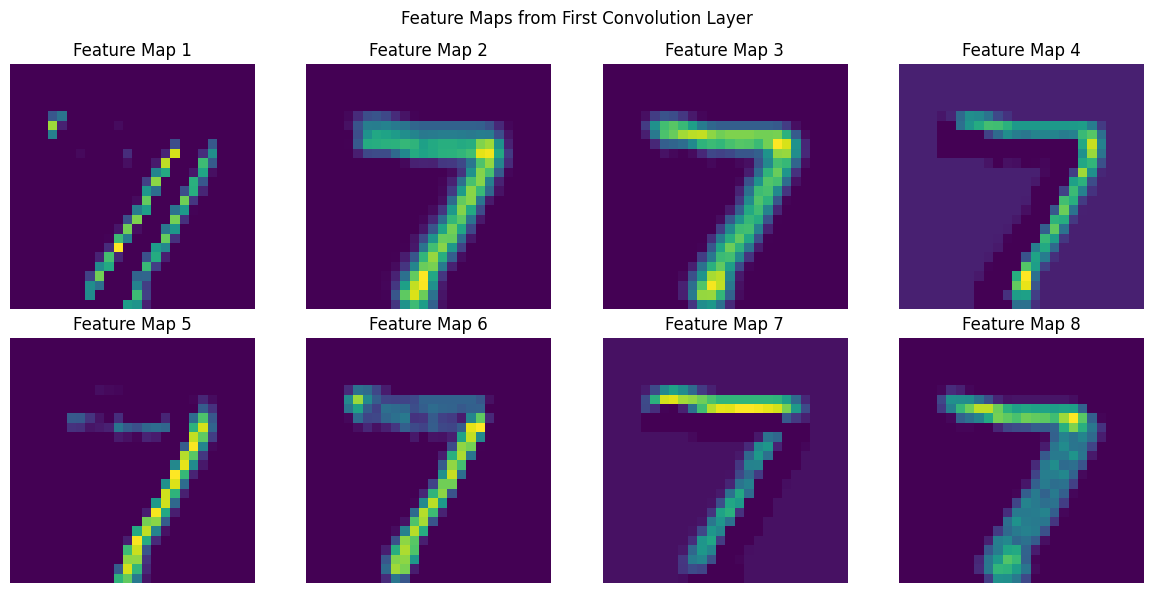

In [11]:
# Pick one test image
sample_image = x_test[0:1]

# Get outputs from convolution layers only
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name.lower()]

# Build activation model
activation_model = tf.keras.Model(inputs=model.inputs, outputs=layer_outputs)

# Get activations
activations = activation_model.predict(sample_image)

# Show original image
plt.figure(figsize=(3, 3))
plt.imshow(sample_image[0].squeeze(), cmap='gray')
plt.title(f"Original Image (Label: {y_test[0]})")
plt.axis('off')
plt.show()

# Plot feature maps from first conv layer
first_layer_activation = activations[0]

plt.figure(figsize=(12, 6))
for i in range(min(8, first_layer_activation.shape[-1])):
    plt.subplot(2, 4, i + 1)
    plt.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    plt.title(f'Feature Map {i+1}')
    plt.axis('off')

plt.suptitle("Feature Maps from First Convolution Layer")
plt.tight_layout()
plt.show()

In [12]:
x_train_small = x_train[:20000]
y_train_small = y_train[:20000]

def run_experiment(dropout_rate=0.3, learning_rate=0.001, filters1=32, filters2=64):
    model = build_model(
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        filters1=filters1,
        filters2=filters2
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=1,
        restore_best_weights=True
    )

    history = model.fit(
        x_train_small, y_train_small,
        epochs=5,
        batch_size=128,
        validation_split=0.1,
        callbacks=[early_stopping],
        verbose=0
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    return history, test_acc

In [19]:
dropout_results = []

dropout_experiments = [
    {"name": "Dropout 0.1", "dropout_rate": 0.1, "learning_rate": 0.001, "filters1": 32, "filters2": 64},
    {"name": "Dropout 0.3", "dropout_rate": 0.3, "learning_rate": 0.001, "filters1": 32, "filters2": 64},
    {"name": "Dropout 0.5", "dropout_rate": 0.5, "learning_rate": 0.001, "filters1": 32, "filters2": 64},
]

for exp in dropout_experiments:
    print(f"Running: {exp['name']}")
    _, test_acc = run_experiment(
        dropout_rate=exp["dropout_rate"],
        learning_rate=exp["learning_rate"],
        filters1=exp["filters1"],
        filters2=exp["filters2"]
    )
    dropout_results.append((exp["name"], test_acc))
    print(f"{exp['name']} Accuracy: {test_acc:.4f}")

print("\nFinal Dropout Results:")
for name, acc in dropout_results:
    print(f"{name}: {acc:.4f}")

Running: Dropout 0.1
Dropout 0.1 Accuracy: 0.9802
Running: Dropout 0.3
Dropout 0.3 Accuracy: 0.9842
Running: Dropout 0.5
Dropout 0.5 Accuracy: 0.9841

Final Dropout Results:
Dropout 0.1: 0.9802
Dropout 0.3: 0.9842
Dropout 0.5: 0.9841


In [14]:
lr_results = []

lr_experiments = [
    {"name": "LR 0.0001", "dropout_rate": 0.3, "learning_rate": 0.0001, "filters1": 32, "filters2": 64},
    {"name": "LR 0.001",  "dropout_rate": 0.3, "learning_rate": 0.001,  "filters1": 32, "filters2": 64},
    {"name": "LR 0.01",   "dropout_rate": 0.3, "learning_rate": 0.01,   "filters1": 32, "filters2": 64},
]

for exp in lr_experiments:
    print(f"Running: {exp['name']}")
    _, test_acc = run_experiment(
        dropout_rate=exp["dropout_rate"],
        learning_rate=exp["learning_rate"],
        filters1=exp["filters1"],
        filters2=exp["filters2"]
    )
    lr_results.append((exp["name"], test_acc))
    print(f"{exp['name']} Accuracy: {test_acc:.4f}")

print("\nFinal Learning Rate Results:")
for name, acc in lr_results:
    print(f"{name}: {acc:.4f}")

Running: LR 0.0001
LR 0.0001 Accuracy: 0.9471
Running: LR 0.001
LR 0.001 Accuracy: 0.9849
Running: LR 0.01
LR 0.01 Accuracy: 0.9757

Final Learning Rate Results:
LR 0.0001: 0.9471
LR 0.001: 0.9849
LR 0.01: 0.9757


In [15]:
filter_results = []

filter_experiments = [
    {"name": "16/32 Filters",  "dropout_rate": 0.3, "learning_rate": 0.001, "filters1": 16, "filters2": 32},
    {"name": "32/64 Filters",  "dropout_rate": 0.3, "learning_rate": 0.001, "filters1": 32, "filters2": 64},
    {"name": "64/128 Filters", "dropout_rate": 0.3, "learning_rate": 0.001, "filters1": 64, "filters2": 128},
]

for exp in filter_experiments:
    print(f"Running: {exp['name']}")
    _, test_acc = run_experiment(
        dropout_rate=exp["dropout_rate"],
        learning_rate=exp["learning_rate"],
        filters1=exp["filters1"],
        filters2=exp["filters2"]
    )
    filter_results.append((exp["name"], test_acc))
    print(f"{exp['name']} Accuracy: {test_acc:.4f}")

print("\nFinal Filter Results:")
for name, acc in filter_results:
    print(f"{name}: {acc:.4f}")

Running: 16/32 Filters
16/32 Filters Accuracy: 0.9782
Running: 32/64 Filters
32/64 Filters Accuracy: 0.9824
Running: 64/128 Filters
64/128 Filters Accuracy: 0.9832

Final Filter Results:
16/32 Filters: 0.9782
32/64 Filters: 0.9824
64/128 Filters: 0.9832


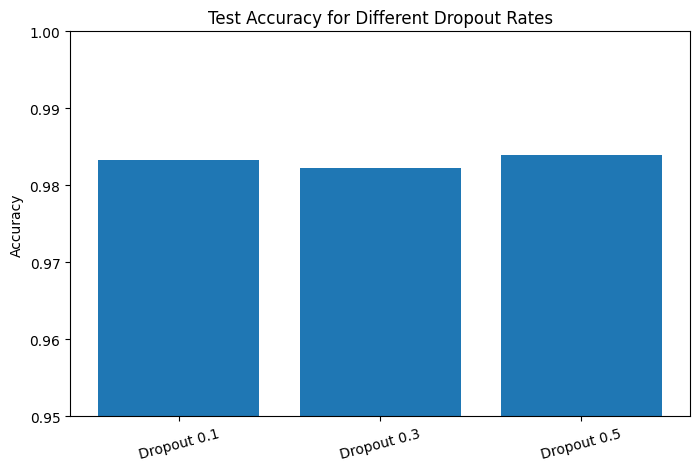

In [16]:
names = [x[0] for x in dropout_results]
accs = [x[1] for x in dropout_results]

plt.figure(figsize=(8, 5))
plt.bar(names, accs)
plt.title("Test Accuracy for Different Dropout Rates")
plt.ylabel("Accuracy")
plt.ylim(0.95, 1.0)
plt.xticks(rotation=15)
plt.show()

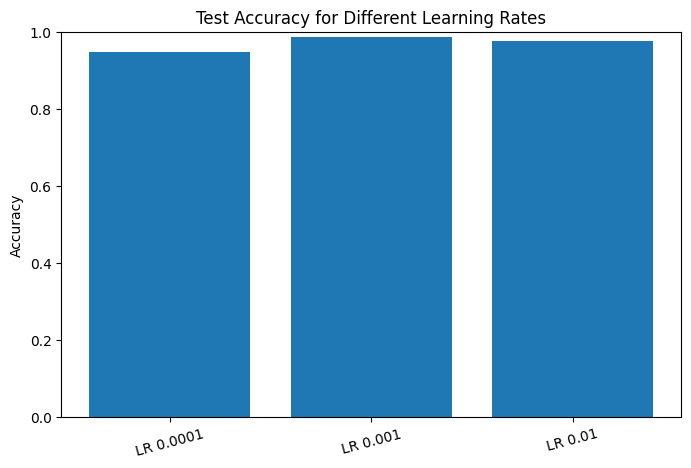

In [17]:
names = [x[0] for x in lr_results]
accs = [x[1] for x in lr_results]

plt.figure(figsize=(8, 5))
plt.bar(names, accs)
plt.title("Test Accuracy for Different Learning Rates")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.0)
plt.xticks(rotation=15)
plt.show()

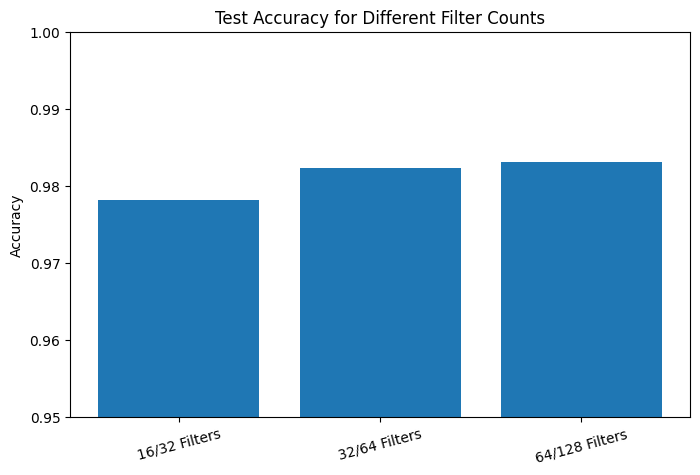

In [18]:
names = [x[0] for x in filter_results]
accs = [x[1] for x in filter_results]

plt.figure(figsize=(8, 5))
plt.bar(names, accs)
plt.title("Test Accuracy for Different Filter Counts")
plt.ylabel("Accuracy")
plt.ylim(0.95, 1.0)
plt.xticks(rotation=15)
plt.show()